In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
sizes = np.random.uniform(50, 200, 30)
prices = sizes * 15 + np.random.normal(0, 200, 30) + 100

# Normalizing helps (gradient descent can get unstable with very large numbers)
sizes_norm = (sizes - sizes.mean()) / sizes.std()

In [7]:
# returns one single number that tells you "how bad is my current line at predicting prices?" A high number = bad fit, low number = good fit
def compute_cost(w, b, x, y):
    m = len(x)
    predictions = w * x + b
    cost = np.sum((predictions - y)**2) / (2*m)
    return cost

In [8]:
def gradient_descent(x, y, w, b, learning_rate, iterations):
    m = len(x)
    cost_history = []
    
    for i in range(iterations):
        predictions = w * x + b
        dw = np.sum((predictions - y) * x) / m
        db = np.sum(predictions - y) / m
        
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        cost_history.append(compute_cost(w, b, x, y))
    
    return w, b, cost_history

w_final, b_final, history = gradient_descent(sizes_norm, prices, w=0, b=0, learning_rate=0.1, iterations=100)
print("Found w:", w_final, "Found b:", b_final)

Found w: 616.525004588144 Found b: 2137.677816866705


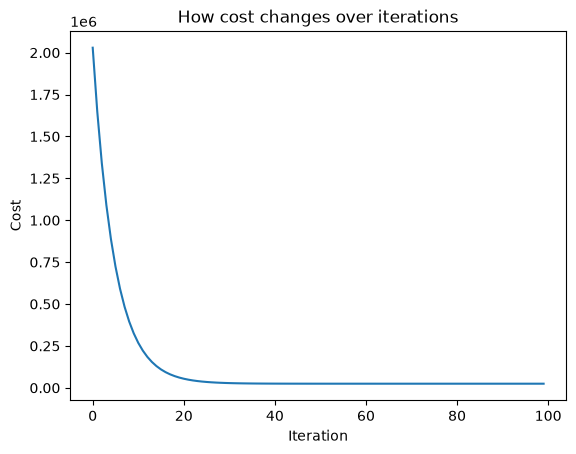

In [9]:
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('How cost changes over iterations')
plt.show()

In [10]:
print(sizes[:5])
print(prices[:5])
print(sizes_norm[:5])
print(sizes_norm.mean(), sizes_norm.std())

[132.32202559 157.27840496 140.41450641 131.73247745 113.5482199 ]
[2257.71762361 2310.74307026 2660.16852096 1785.11402682 1812.37500197]
[-0.11530986  0.47852063  0.07724859 -0.129338   -0.56202763]
4.4408920985006264e-17 1.0


In [11]:
print("std of sizes:", sizes.std())
print("expected w in normalized space (~15 * std):", 15 * sizes.std())
print("expected b in normalized space (~ mean price, roughly):", prices.mean())

std of sizes: 42.026100063420884
expected w in normalized space (~15 * std): 630.3915009513132
expected b in normalized space (~ mean price, roughly): 2137.7345980880814


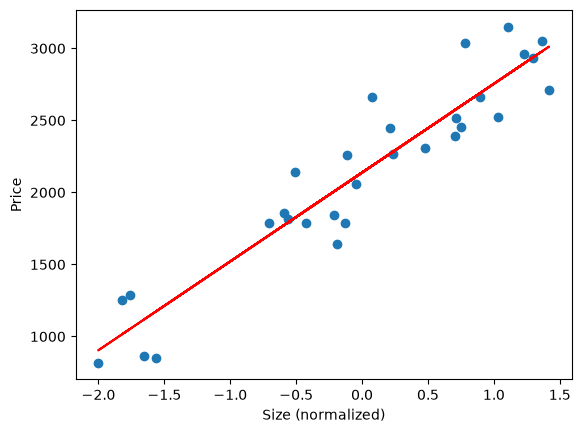

In [12]:
plt.scatter(sizes_norm, prices)
plt.plot(sizes_norm, w_final*sizes_norm + b_final, color='red')
plt.xlabel('Size (normalized)')
plt.ylabel('Price')
plt.show()